In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [2]:
data = pd.read_csv("breast-cancer.csv")

In [3]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [4]:
data.head(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
data.shape

(569, 33)

In [6]:
data = data.dropna(axis=1, how="all") # aca estamos eliminando datos nulos 

In [ ]:
data = data.loc[:,data.columns.str.contains("^Unnamed")]


In [ ]:
data.shape

In [7]:
print(data.isna().sum())

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [8]:
nulos = data.isna().sum()
print("\nColumnas que todavia contienen datos nulos:")
if nulos [nulos > 0].empty:
    print("No existe valores nulos")
else:
    print(nulos[nulos>0])


Columnas que todavia contienen datos nulos:
No existe valores nulos


In [9]:

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [10]:
data.describe().T # se muestra estadistica descriptiva 

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [11]:
data ['diagnosis'].value_counts() ## variable objetivo

diagnosis
B    357
M    212
Name: count, dtype: int64

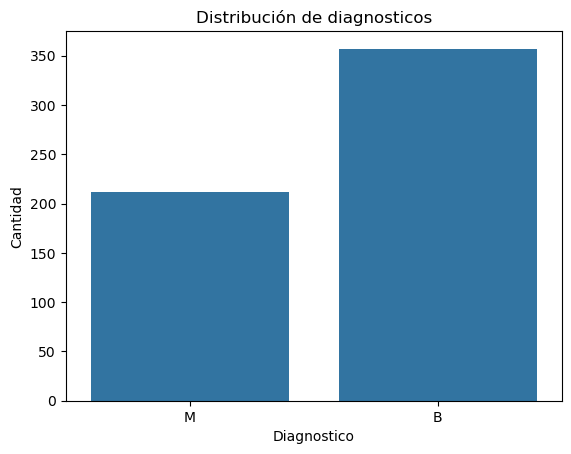

In [12]:
# B = Benigno 
# M = Maligno
sns.countplot(data=data, x='diagnosis')
plt.title("Distribución de diagnosticos")
plt.xlabel('Diagnostico')
plt.ylabel('Cantidad')
plt.show()

In [13]:
data.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [14]:
data['diagnosis'].value_counts(dropna=False)

diagnosis
B    357
M    212
Name: count, dtype: int64

In [15]:
data['diagnosis'].unique()

array(['M', 'B'], dtype=object)

In [16]:
data= data.drop(columns=['id']) # estoy eliminanbdo una columna, la columna ID

In [17]:
data.head(2)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902


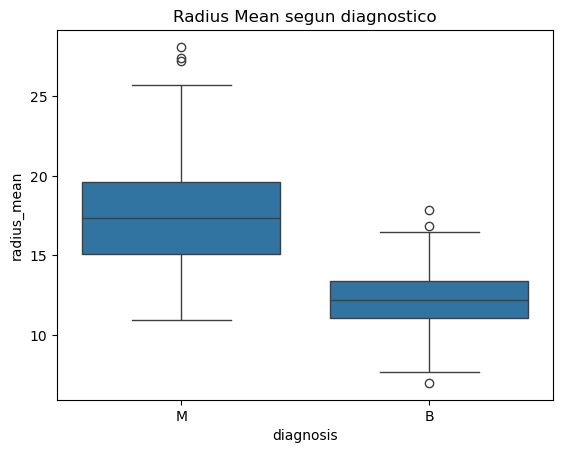

In [19]:
sns.boxplot(data =data, x='diagnosis', y='radius_mean' )
plt.title('Radius Mean segun diagnostico')
plt.show()

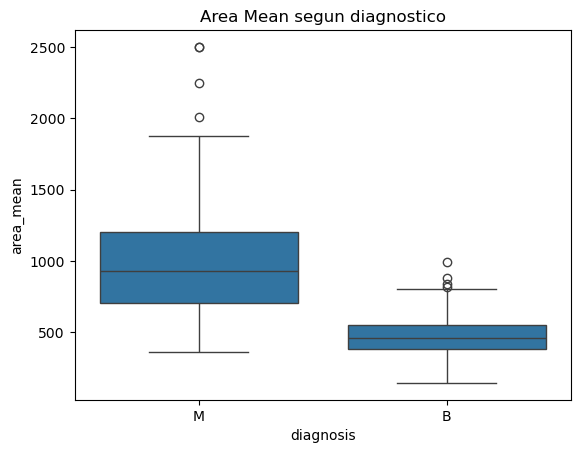

In [20]:
sns.boxplot(data =data, x='diagnosis', y='area_mean' )
plt.title('Area Mean segun diagnostico')
plt.show()

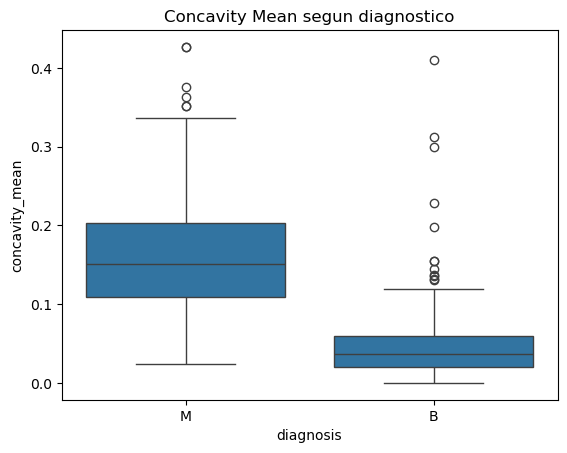

In [21]:
sns.boxplot(data =data, x='diagnosis', y='concavity_mean' )
plt.title('Concavity Mean segun diagnostico')
plt.show()

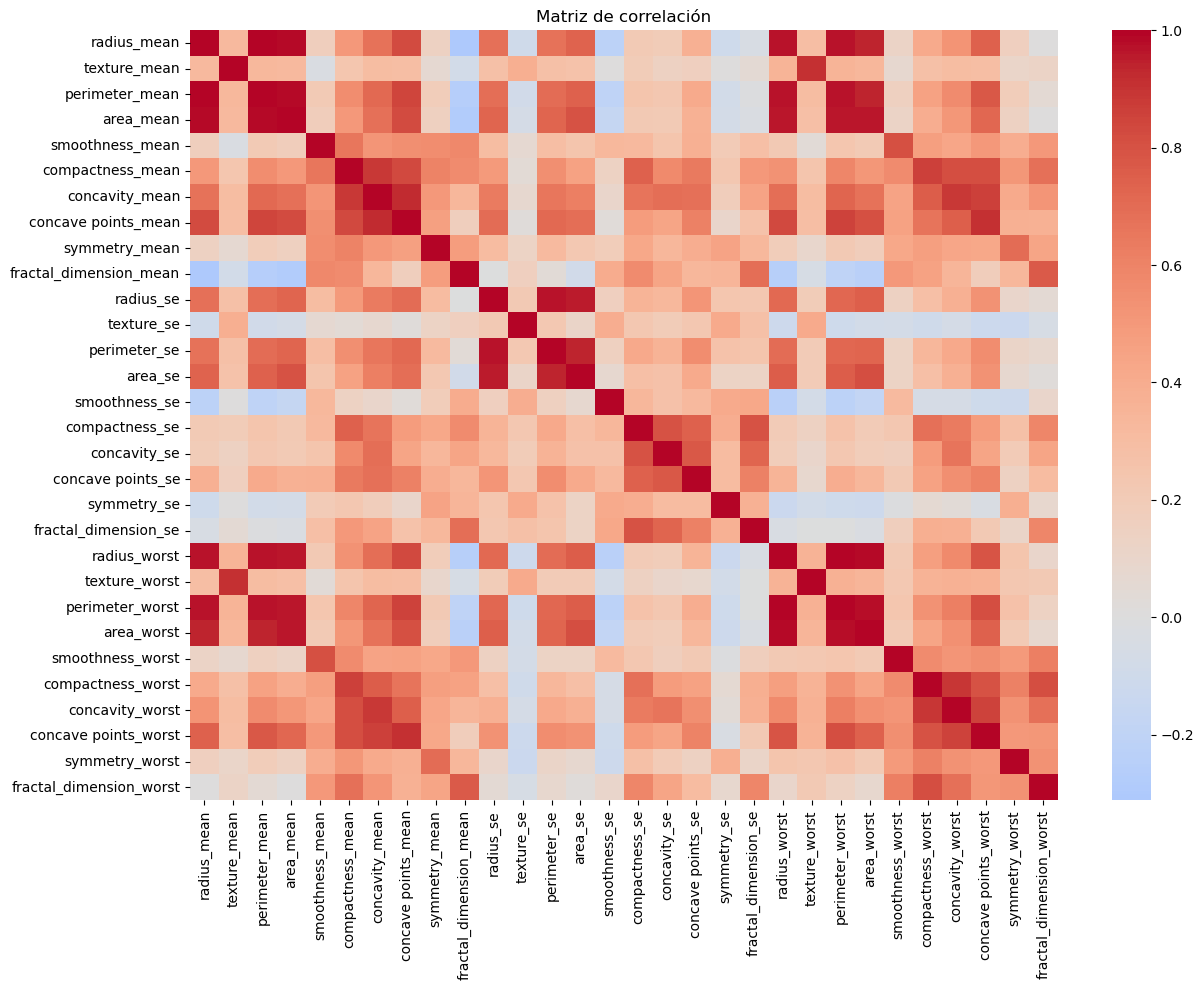

In [22]:
plt.figure(figsize=(14,10))
sns.heatmap(
    data.drop(columns='diagnosis').corr(),
    cmap='coolwarm',
    center=0
)
plt.title('Matriz de correlación')
plt.show()

# preparacion de los datos 

In [23]:
# Benigno = B = 0 
# Maligno = M = 1

In [24]:
data.head(3)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [25]:
data['diagnosis'] = data['diagnosis'].map({
    'B': 0,
    'M': 1
})

In [26]:
data.head(3)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [27]:
X = data.drop(columns='diagnosis')
y = data['diagnosis']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [29]:
scaler = StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

In [32]:
print(accuracy_score(y_test, y_pred_knn))

0.956140350877193


In [33]:
print(confusion_matrix(y_test, y_pred_knn))

[[71  1]
 [ 4 38]]


In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred_knn))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [36]:
## MODELO NAIVE BAYES 

In [37]:
from sklearn.naive_bayes import GaussianNB

In [38]:
nb=GaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_test_scaled)

In [39]:
print(accuracy_score(y_test,y_pred_nb))

0.9210526315789473


In [40]:
print(confusion_matrix(y_test, y_pred_nb))

[[69  3]
 [ 6 36]]


In [41]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94        72
           1       0.92      0.86      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114



In [42]:
# MODELO: SVM 

In [43]:
# from sklearn.svm import SVC 

In [44]:
svm = SVC(
    kernel='linear',
    probability=True,
    random_state=42
)

svm.fit(X_train_scaled,y_train)
y_pred_svm = svm.predict(X_test_scaled)

In [45]:
print(accuracy_score(y_test,y_pred_svm))

0.9649122807017544


In [46]:
print(confusion_matrix(y_test, y_pred_svm))

[[72  0]
 [ 4 38]]


In [47]:
print(classification_report(y_test,y_pred_svm))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
 
resultados = pd.DataFrame({
    'Modelo': ['KNN', 'Naive Bayes', 'SVM'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm)
    ],
    'Precision': [
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_svm)
    ],
    'Recall': [
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_svm)
    ],
    'F1': [
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_svm)
    ]
})
 
resultados

,Modelo,Accuracy,Precision,Recall,F1
0,KNN,0.956140,0.974359,0.904762,0.938272
1,Naive Bayes,0.921053,0.923077,0.857143,0.888889
2,SVM,0.964912,1.000000,0.904762,0.950000


In [49]:
prob_knn=knn.predict_proba(X_test_scaled)[:,1]
prob_nb=nb.predict_proba(X_test_scaled)[:,1]
prob_svm=svm.predict_proba(X_test_scaled)[:,1]

auc_knn=roc_auc_score(y_test, prob_knn)
auc_nb=roc_auc_score(y_test, prob_nb)
auc_svm=roc_auc_score(y_test, prob_svm)

print('knn:', auc_knn)
print('Naive Bayes:', auc_nb)
print('SVM:', auc_svm)


knn: 0.982308201058201
Naive Bayes: 0.9890873015873015
SVM: 0.9914021164021164


In [50]:
# KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test, prob_knn)
auc_knn = auc(fpr_knn, tpr_knn)
 
# Naive Bayes
fpr_nb, tpr_nb, _ = roc_curve(y_test, prob_nb)
auc_nb = auc(fpr_nb, tpr_nb)
 
# SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, prob_svm)
auc_svm = auc(fpr_svm, tpr_svm)

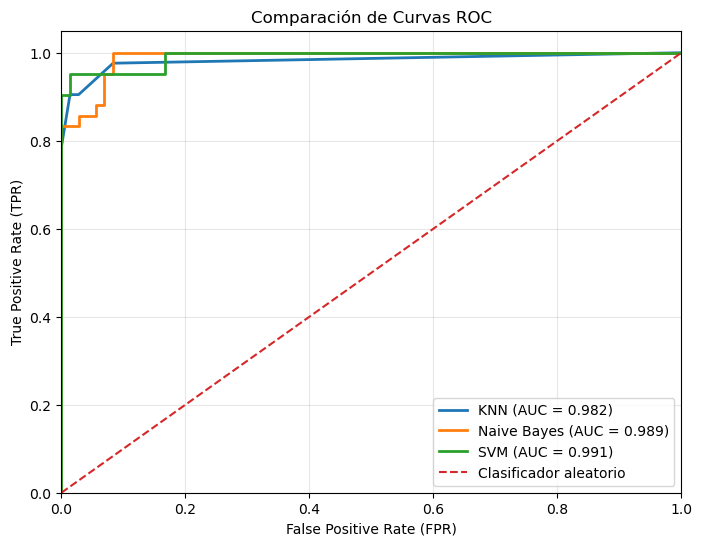

In [51]:
plt.figure(figsize=(8, 6))
 
plt.plot(
    fpr_knn,
    tpr_knn,
    linewidth=2,
    label=f'KNN (AUC = {auc_knn:.3f})'
)
 
plt.plot(
    fpr_nb,
    tpr_nb,
    linewidth=2,
    label=f'Naive Bayes (AUC = {auc_nb:.3f})'
)
 
plt.plot(
    fpr_svm,
    tpr_svm,
    linewidth=2,
    label=f'SVM (AUC = {auc_svm:.3f})'
)
 
# Línea de referencia: clasificador aleatorio
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1.5,
    label='Clasificador aleatorio'
)
 
# Ejes
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
 
# Límites
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
 
# Título
plt.title('Comparación de Curvas ROC')
 
# Cuadrícula
plt.grid(True, alpha=0.3)
 
# Leyenda
plt.legend(loc='lower right')
 
plt.show()

In [52]:
# SVM : 
#LINEAR 
#RBF 
#C
#GAMMA


In [53]:
#SVM CON RBF 

In [55]:
svm_rbf = SVC(
    kernel="rbf",
    C=1,
    gamma="scale",
    probability=True,
    random_state=42
)

svm_rbf.fit(X_train_scaled, y_train)
y_pred_rbf=svm_rbf.predict(X_test_scaled)
prob_rbf = svm_rbf.predict_proba(
    X_test_scaled
)[:,1]

print("Accuracy:",accuracy_score(y_test,y_pred_rbf))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_rbf))

print("\nReporte:")
print(classification_report(y_test, y_pred_rbf))
print(
    "ROC-AUC:",
    roc_auc_score(y_test, prob_rbf)
)

Accuracy: 0.9736842105263158

Matriz de confusión:
[[72  0]
 [ 3 39]]

Reporte:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

ROC-AUC: 0.9947089947089947


In [56]:
# con SVM con C


In [57]:
valores_C = [0.01, 0.1, 1,10,100]
resultado_C=[]


In [60]:
valores_C = [0.01, 0.1, 1, 10, 100]
resultados_C = []
# c se encarga de controlar cuanto penaliza SVM los errores de clasificacion 
for c in valores_C:
  modelo = SVC(
    kernel="rbf",
    C=c,
    gamma="scale",
    probability=True,
    random_state=42
  )

  modelo.fit(X_train_scaled, y_train)
  pred = modelo.predict(X_test_scaled)
  prob = modelo.predict_proba(
    X_test_scaled
  )[:, 1]

  resultados_C.append({
    "C": c,
    "Accuracy": accuracy_score(y_test, pred),
    "Precision": precision_score(y_test, pred),
    "Recall": recall_score(y_test, pred),
    "F1": f1_score(y_test, pred),
    "ROC-AUC": roc_auc_score(y_test, prob)
  })

resultados_C = pd.DataFrame(resultados_C)
print(resultados_C)


        C  Accuracy  Precision    Recall        F1   ROC-AUC
0    0.01  0.631579   0.000000  0.000000  0.000000  0.985119
1    0.10  0.947368   1.000000  0.857143  0.923077  0.989418
2    1.00  0.973684   1.000000  0.928571  0.962963  0.994709
3   10.00  0.973684   1.000000  0.928571  0.962963  0.992725
4  100.00  0.964912   0.952381  0.952381  0.952381  0.984788


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [61]:
# SVM CON GAMMA 



In [62]:
valores_gamma=[
    0.001,
    0.01,
    0.1,
    1
]
resultados_gamma = []
for gamma in valores_gamma:
    modelo = SVC(
        kernel ="rbf",
        C=1,
        gamma = gamma,
        probability = True,
        random_state=42
    )

    modelo.fit(X_train_scaled, y_train)
    pred = modelo.predict(X_test_scaled)
    prob = modelo.predict_proba(
        X_test_scaled
    )[:,1]

    resultados_gamma.append({
        "Gamma": gamma,
        "Accuracy": accuracy_score(y_test,pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC":roc_auc_score(y_test, prob)
    })

resultados_gamma = pd.DataFrame(resultados_gamma)
print(resultados_gamma)
    
    



   Gamma  Accuracy  Precision    Recall        F1   ROC-AUC
0  0.001  0.938596   1.000000  0.833333  0.909091  0.997685
1  0.010  0.956140   1.000000  0.880952  0.936709  0.996362
2  0.100  0.929825   0.886364  0.928571  0.906977  0.986111
3  1.000  0.631579   0.000000  0.000000  0.000000  0.950397


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [65]:
resultados = pd.DataFrame({

  "Modelo": [
    "SVM Linear",
    "SVM RBF"

  ],

  "Accuracy": [
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_rbf)
  ],

  "Precision": [
    precision_score(y_test, y_pred_svm),
    precision_score(y_test, y_pred_rbf)
  ],

  "Recall": [
    recall_score(y_test, y_pred_svm),
    recall_score(y_test, y_pred_rbf)
  ],

  "F1": [
    f1_score(y_test, y_pred_svm),
    f1_score(y_test, y_pred_rbf)
  ],
  "ROC-AUC": [
    roc_auc_score(y_test, prob_svm),
    roc_auc_score(y_test, prob_rbf)
  ]

})

print(resultados)

       Modelo  Accuracy  Precision    Recall        F1   ROC-AUC
0  SVM Linear  0.964912        1.0  0.904762  0.950000  0.991402
1     SVM RBF  0.973684        1.0  0.928571  0.962963  0.994709


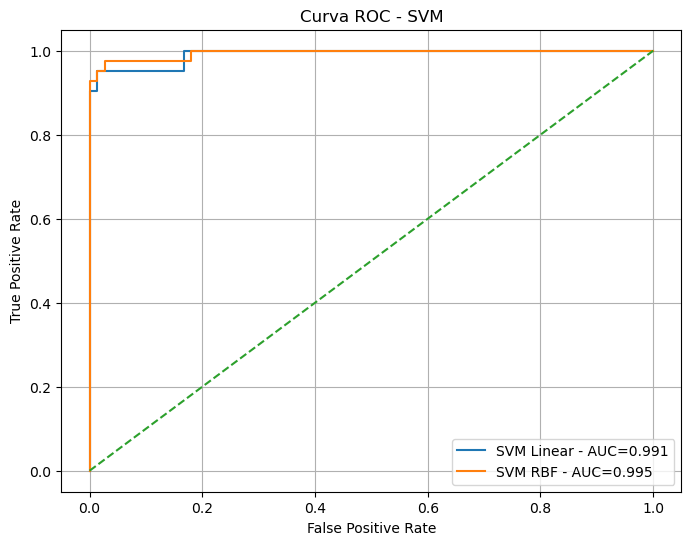

In [69]:
from sklearn.metrics import roc_curve
fpr_linear, tpr_linear, _ = roc_curve(
  y_test,   prob_svm )
fpr_rbf, tpr_rbf, _ = roc_curve(
  y_test,
  prob_rbf
)

auc_linear = roc_auc_score(y_test, prob_svm)
auc_rbf = roc_auc_score(y_test, prob_rbf)

plt.figure(figsize=(8, 6))
plt.plot(
  fpr_linear,
  tpr_linear,
  label=f"SVM Linear - AUC={auc_linear:.3f}"
)

plt.plot(
  fpr_rbf,
  tpr_rbf,
  label=f"SVM RBF - AUC={auc_rbf:.3f}"
)

plt.plot(
  [0, 1],
  [0, 1],
  linestyle="--"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - SVM")
plt.legend()
plt.grid()
plt.show()